In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt   
import seaborn as sns
import sklearn
import tensorflow as tf



In [24]:
df = pd.read_excel(r'E:\\DS\\tezendra\\Projects\\Segmenting and Classifying the Best Strikers\\Strikers_performance.xlsx')
df.head(5)

,Striker_ID,Nationality,Footedness,Marital Status,Goals Scored,Assists,Shots on Target,Shot Accuracy,Conversion Rate,Dribbling Success,Movement off the Ball,Hold-up Play,Aerial Duels Won,Defensive Contribution,Big Game Performance,Consistency,Penalty Success Rate,Impact on Team Performance,Off-field Conduct
0,1,Spain,Left-footed,No,17.483571,10.778533,34.795488,0.677836,0.166241,0.757061,50.921924,71.806409,15.682532,30.412215,6.152481,0.820314,0.922727,8.570370,11.451388
1,2,France,Left-footed,Yes,14.308678,13.728250,31.472436,0.544881,0.192774,0.796818,61.396150,53.726866,19.843983,26.474913,6.093172,0.803321,0.678984,3.444638,8.243689
2,3,Germany,Left-footed,No,18.238443,3.804297,25.417413,0.518180,0.160379,0.666869,65.863945,60.452227,20.090084,24.164116,3.408714,0.766540,0.843858,8.429491,9.506835
3,4,France,Right-footed,No,22.615149,9.688908,20.471443,0.599663,0.184602,0.638776,88.876877,60.511979,22.363152,44.129989,6.339820,0.611798,0.662997,6.532552,8.199653
4,5,France,Left-footed,Yes,13.829233,6.048072,29.887563,0.582982,0.105319,0.591485,75.565531,54.982158,13.165708,37.859323,8.465658,0.701638,0.906538,8.414915,6.665333


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 19 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Striker_ID                  500 non-null    int64  
 1   Nationality                 500 non-null    object 
 2   Footedness                  500 non-null    object 
 3   Marital Status              500 non-null    object 
 4   Goals Scored                500 non-null    float64
 5   Assists                     500 non-null    float64
 6   Shots on Target             500 non-null    float64
 7   Shot Accuracy               500 non-null    float64
 8   Conversion Rate             500 non-null    float64
 9   Dribbling Success           500 non-null    float64
 10  Movement off the Ball       494 non-null    float64
 11  Hold-up Play                500 non-null    float64
 12  Aerial Duels Won            500 non-null    float64
 13  Defensive Contribution      500 non

In [26]:
Null_values = df.isnull().sum()
print(Null_values)

Striker_ID                    0
Nationality                   0
Footedness                    0
Marital Status                0
Goals Scored                  0
Assists                       0
Shots on Target               0
Shot Accuracy                 0
Conversion Rate               0
Dribbling Success             0
Movement off the Ball         6
Hold-up Play                  0
Aerial Duels Won              0
Defensive Contribution        0
Big Game Performance          2
Consistency                   0
Penalty Success Rate          5
Impact on Team Performance    0
Off-field Conduct             0
dtype: int64


In [29]:
df.describe()

,Striker_ID,Goals Scored,Assists,Shots on Target,Shot Accuracy,Conversion Rate,Dribbling Success,Movement off the Ball,Hold-up Play,Aerial Duels Won,Defensive Contribution,Big Game Performance,Consistency,Penalty Success Rate,Impact on Team Performance,Off-field Conduct
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,494.000000,500.000000,500.000000,500.000000,498.000000,500.000000,495.000000,500.000000,500.000000
mean,250.500000,15.036603,8.095660,25.759392,0.603319,0.199424,0.702133,69.790151,59.810879,19.529831,39.954865,6.928509,0.743628,0.795525,7.012619,8.064249
std,144.481833,4.898554,2.933487,7.071724,0.098407,0.047978,0.100108,10.400347,10.167912,4.958031,9.921254,1.940599,0.103619,0.103053,2.100270,2.068334
min,1.000000,0.000000,0.000000,4.726212,0.305961,0.049024,0.400886,40.705513,35.067292,4.961838,8.232962,2.231386,0.460049,0.529246,0.557967,0.623269
25%,125.750000,11.498463,6.214125,20.782993,0.538806,0.166963,0.637285,62.668746,52.425012,16.395836,33.458187,5.683096,0.675834,0.723800,5.656504,6.615688
50%,250.500000,15.063986,8.085595,25.838641,0.599109,0.199842,0.700354,69.617049,60.075293,19.741772,39.978322,6.912446,0.745519,0.795853,6.991318,8.016586
75%,375.250000,18.183916,9.953727,30.283169,0.669977,0.233459,0.763227,76.953526,66.033512,22.856931,46.693579,8.177377,0.812646,0.869923,8.431703,9.452531
max,500.000000,34.263657,15.897146,43.211782,0.919311,0.355496,1.000000,98.684031,92.430930,34.073272,71.129102,12.871316,1.000000,1.000000,13.235362,13.730424


In [ ]:
from sklearn.impute import SimpleImputer

# Impute missing values with the mean of each feature
imputer = SimpleImputer(strategy='mean')
# Separate numeric and non-numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns

# Impute missing values in numeric columns
imputer_numeric = SimpleImputer(strategy='mean')
df_numeric_imputed = pd.DataFrame(imputer_numeric.fit_transform(df[numeric_cols]), columns=numeric_cols)

# Impute missing values in non-numeric columns
imputer_non_numeric = SimpleImputer(strategy='most_frequent')
df_non_numeric_imputed = pd.DataFrame(imputer_non_numeric.fit_transform(df[non_numeric_cols]), columns=non_numeric_cols)

# Combine the imputed numeric and non-numeric columns
df_imputed = pd.concat([df_numeric_imputed, df_non_numeric_imputed], axis=1)

print(df_imputed.head(5))

print(df_imputed.head(5))

   Striker_ID  Goals Scored    Assists  Shots on Target  Shot Accuracy  \
0         1.0     17.483571  10.778533        34.795488       0.677836   
1         2.0     14.308678  13.728250        31.472436       0.544881   
2         3.0     18.238443   3.804297        25.417413       0.518180   
3         4.0     22.615149   9.688908        20.471443       0.599663   
4         5.0     13.829233   6.048072        29.887563       0.582982   

   Conversion Rate  Dribbling Success  Movement off the Ball  Hold-up Play  \
0         0.166241           0.757061              50.921924     71.806409   
1         0.192774           0.796818              61.396150     53.726866   
2         0.160379           0.666869              65.863945     60.452227   
3         0.184602           0.638776              88.876877     60.511979   
4         0.105319           0.591485              75.565531     54.982158   

   Aerial Duels Won  Defensive Contribution  Big Game Performance  \
0         15.6825

In [31]:
df_imputed.describe()

,Striker_ID,Goals Scored,Assists,Shots on Target,Shot Accuracy,Conversion Rate,Dribbling Success,Movement off the Ball,Hold-up Play,Aerial Duels Won,Defensive Contribution,Big Game Performance,Consistency,Penalty Success Rate,Impact on Team Performance,Off-field Conduct
count,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,250.500000,15.036603,8.095660,25.759392,0.603319,0.199424,0.702133,69.790151,59.810879,19.529831,39.954865,6.928509,0.743628,0.795525,7.012619,8.064249
std,144.481833,4.898554,2.933487,7.071724,0.098407,0.047978,0.100108,10.337631,10.167912,4.958031,9.921254,1.936706,0.103619,0.102535,2.100270,2.068334
min,1.000000,0.000000,0.000000,4.726212,0.305961,0.049024,0.400886,40.705513,35.067292,4.961838,8.232962,2.231386,0.460049,0.529246,0.557967,0.623269
25%,125.750000,11.498463,6.214125,20.782993,0.538806,0.166963,0.637285,62.695399,52.425012,16.395836,33.458187,5.685446,0.675834,0.723933,5.656504,6.615688
50%,250.500000,15.063986,8.085595,25.838641,0.599109,0.199842,0.700354,69.790151,60.075293,19.741772,39.978322,6.918813,0.745519,0.795525,6.991318,8.016586
75%,375.250000,18.183916,9.953727,30.283169,0.669977,0.233459,0.763227,76.933428,66.033512,22.856931,46.693579,8.133822,0.812646,0.869536,8.431703,9.452531
max,500.000000,34.263657,15.897146,43.211782,0.919311,0.355496,1.000000,98.684031,92.430930,34.073272,71.129102,12.871316,1.000000,1.000000,13.235362,13.730424


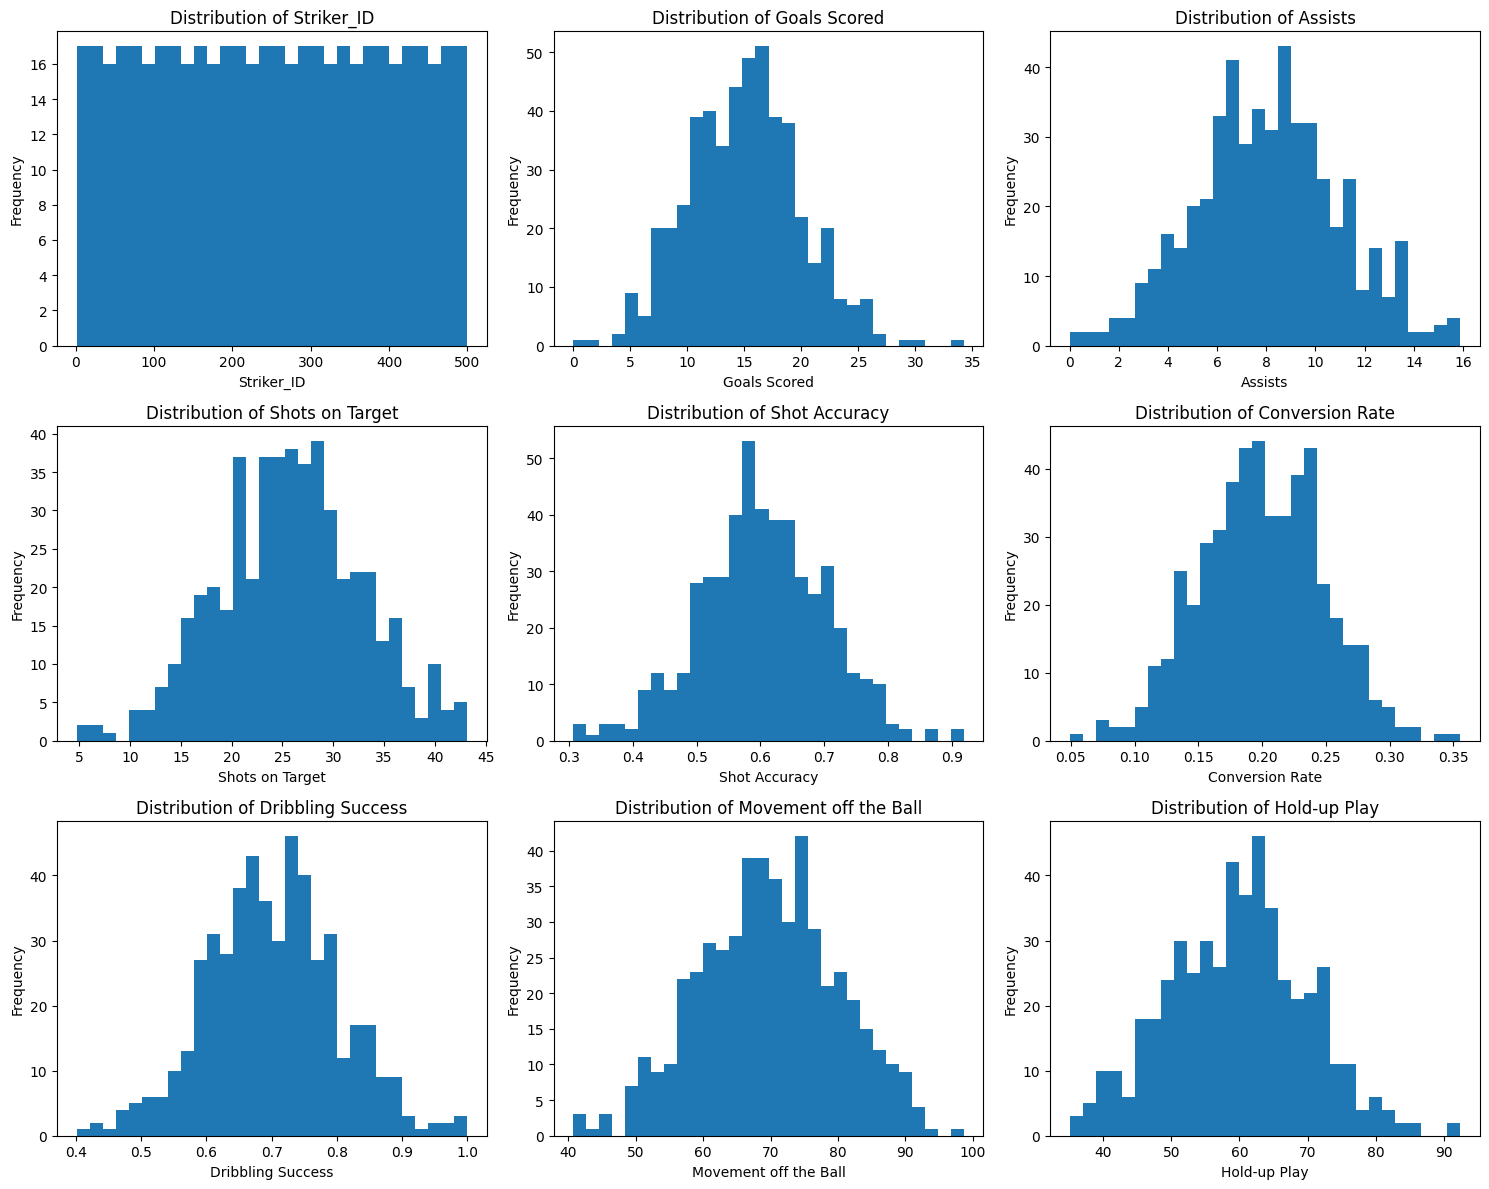

In [44]:
plt.figure(figsize=(15, 12))

num = 9  
for i, column in enumerate(df_imputed.columns[:num]):
    plt.subplot(3, 3, i + 1)
    plt.hist(df_imputed[column], bins=30)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()


In [46]:
z_scores = np.abs((df_imputed[numeric_cols] - df_imputed[numeric_cols].mean()) / df_imputed[numeric_cols].std())
print(z_scores.head(5))

   Striker_ID  Goals Scored   Assists  Shots on Target  Shot Accuracy  \
0    1.726861      0.499529  0.914568         1.277778       0.757239   
1    1.719939      0.148600  1.920100         0.807871       0.593836   
2    1.713018      0.653630  1.462888         0.048359       0.865172   
3    1.706097      1.547099  0.543124         0.747760       0.037154   
4    1.699176      0.246475  0.698004         0.583757       0.206666   

   Conversion Rate  Dribbling Success  Movement off the Ball  Hold-up Play  \
0         0.691627           0.548689               1.825198      1.179744   
1         0.138607           0.945832               0.811985      0.598354   
2         0.813809           0.352261               0.379797      0.063076   
3         0.308937           0.632886               1.846335      0.068952   
4         1.961405           1.105291               0.558675      0.474898   

   Aerial Duels Won  Defensive Contribution  Big Game Performance  \
0          0.775973    

In [49]:
df_outliers_removed = df_imputed[(z_scores < 3).all(axis=1)]
print(df_outliers_removed.head(5))

   Striker_ID  Goals Scored    Assists  Shots on Target  Shot Accuracy  \
0         1.0     17.483571  10.778533        34.795488       0.677836   
1         2.0     14.308678  13.728250        31.472436       0.544881   
2         3.0     18.238443   3.804297        25.417413       0.518180   
3         4.0     22.615149   9.688908        20.471443       0.599663   
4         5.0     13.829233   6.048072        29.887563       0.582982   

   Conversion Rate  Dribbling Success  Movement off the Ball  Hold-up Play  \
0         0.166241           0.757061              50.921924     71.806409   
1         0.192774           0.796818              61.396150     53.726866   
2         0.160379           0.666869              65.863945     60.452227   
3         0.184602           0.638776              88.876877     60.511979   
4         0.105319           0.591485              75.565531     54.982158   

   Aerial Duels Won  Defensive Contribution  Big Game Performance  \
0         15.6825

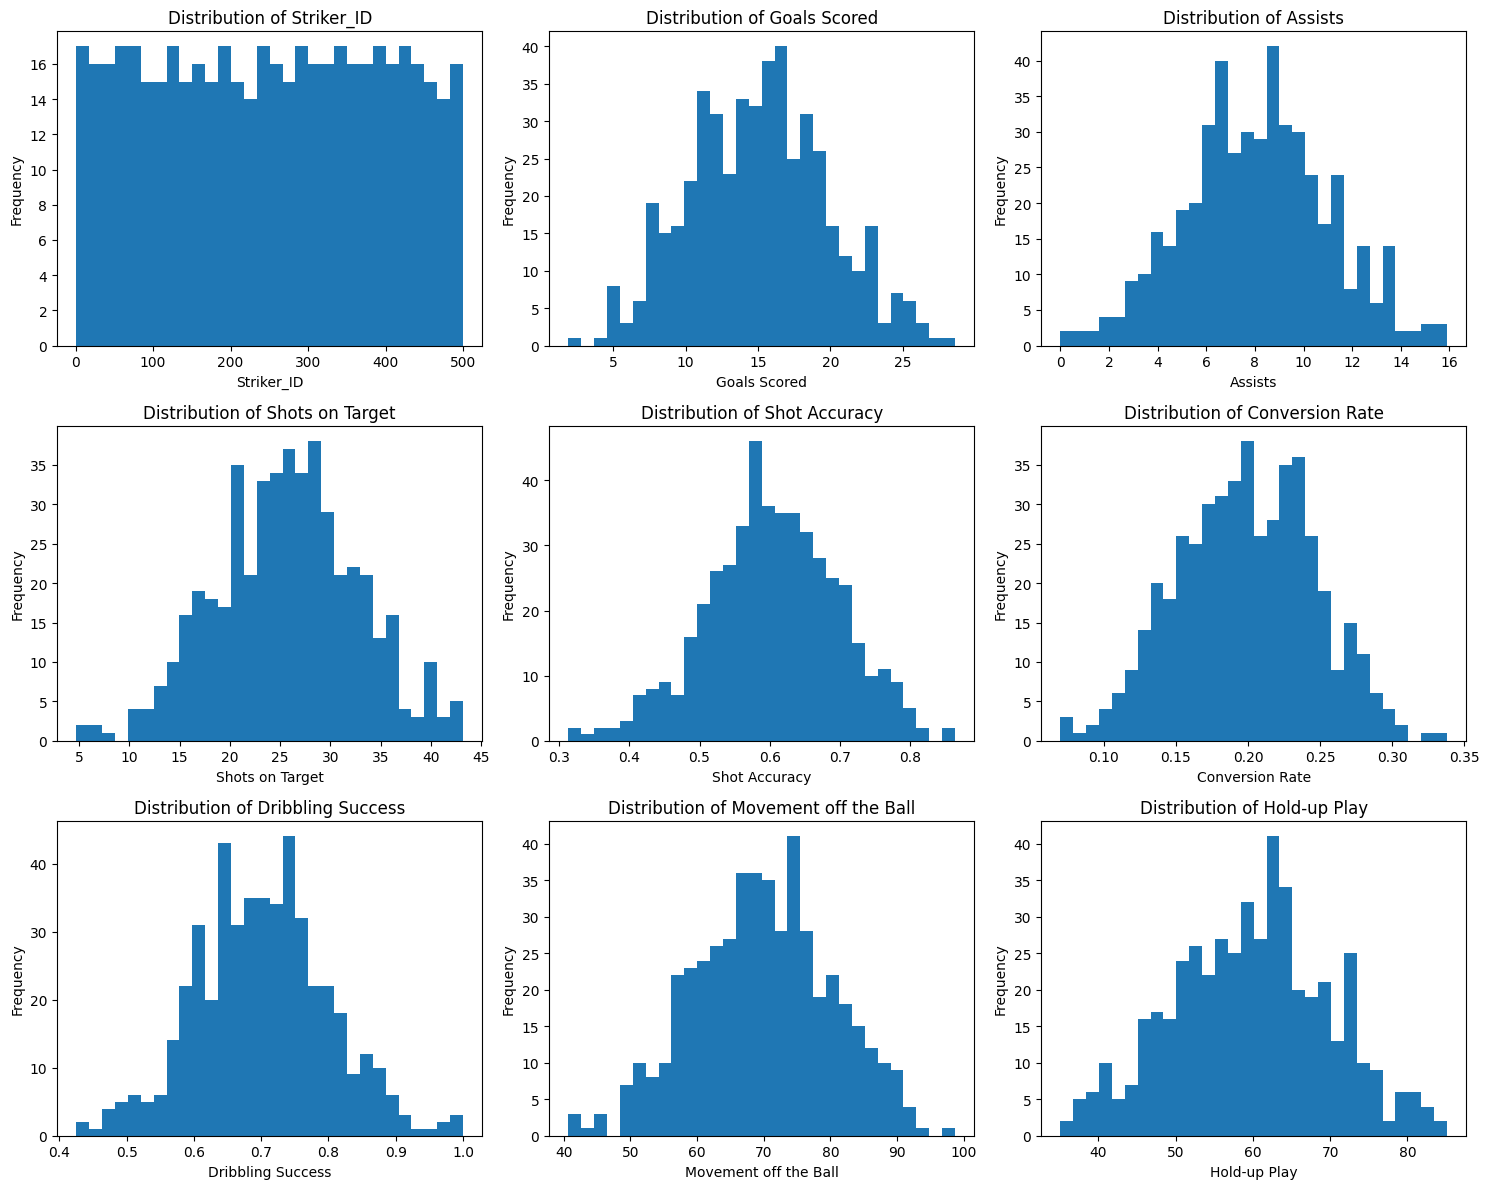

In [50]:
plt.figure(figsize=(15, 12))

num = 9  
for i, column in enumerate(df_outliers_removed.columns[:num]):
    plt.subplot(3, 3, i + 1)
    plt.hist(df_outliers_removed[column], bins=30)
    plt.title(f'Distribution of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [54]:
def visualize_correlation_matrix(df_outliers_removed):
    """
    Visualize the correlation matrix using a heatmap, including only numeric columns.

    Parameters:
    - data: DataFrame containing the features to be analyzed.
    """
    # Select only numeric columns
    df_numeric = df_outliers_removed.select_dtypes(include=[np.number])

    # Calculate the correlation matrix
    corr = df_numeric.corr()
    # Generate a mask for the upper triangle
    mask = np.triu(np.ones_like(corr, dtype=bool))
    
    # Set up the matplotlib figure
    plt.figure(figsize=(12, 10))
    
    # Draw the heatmap with the mask and correct aspect ratio
    sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm')
    
    # Show the plot
    plt.show()

# Example usage:
# Assuming 'df' is your DataFrame
# visualize_correlation_matrix(df)

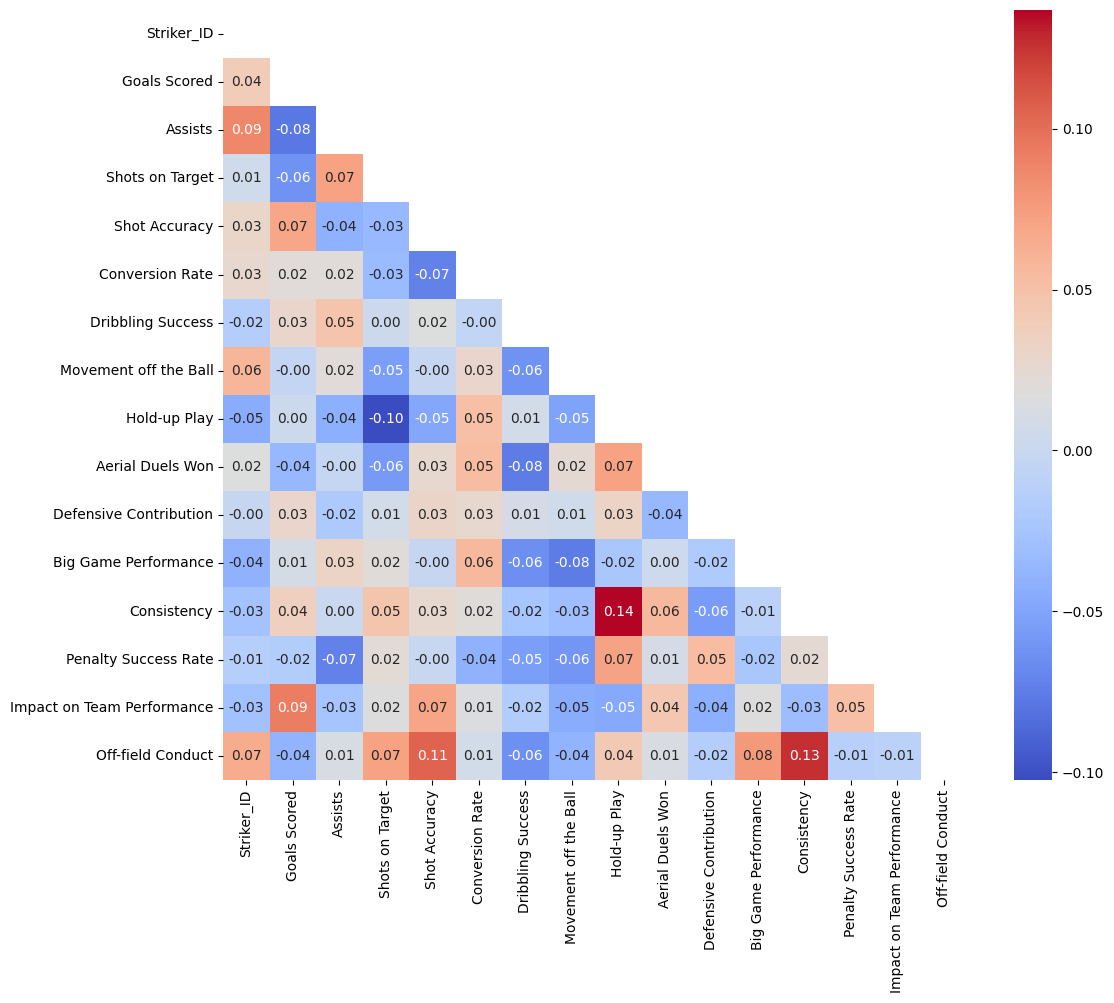

In [55]:
visualize_correlation_matrix(df_outliers_removed)